# 07-13: Analyse der Spalte `won_how`

## Kontext
Die Spalte `won_how` stammt aus den PCS-Etappen-Metadaten (Feld **„Won how“**) und beschreibt, **wie der Etappensieger gewonnen hat** — z. B. Massensprint, Solo mit Angriffsdistanz oder Zeitfahren. Sie wird beim Scraping auf alle Fahrer-Zeilen einer Etappe gemerged ([`01_stage_results.py`](../../scraping/code/01_stage_results.py)).

**Abgrenzung:** Die Fahrer-Profilscores `sprint`, `climber`, `time_trial` usw. sind **ex-ante** PCS-Stärkenprofile. `won_how` ist dagegen eine **ex-post** Beschreibung des realisierten Renngeschehens.

## Zielsetzung
1. Verteilung der Zieleinlauf-Arten (roh und aggregiert)
2. Transformationsvorschläge für ML-Modelle
3. Bewertung der **Data-Leakage-Gefahr** für die Zielvariable `rank`
4. **Transformation:** `won_how` → `won_how_cat` und Speicherung als `22_cleaned_master_data.pkl`

> Die Projektentscheidung zur Feature-Auswahl steht in [08_Feature_Selection.md](08_Feature_Selection.md). Auch `won_how_cat` ist post-race und wird für das Ranking-Modell nicht genutzt.

In [1]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 30)
pd.set_option("display.width", 160)

In [2]:
DATA_PATH = "../../data/processed/20_cleaned_master_data.pkl"
df = pd.read_pickle(DATA_PATH)

print(f"Shape: {df.shape[0]:,} Zeilen x {df.shape[1]} Spalten")
print(f"\nwon_how: dtype={df['won_how'].dtype}, nunique={df['won_how'].nunique()}")
print(f"Platzhalter '-': {(df['won_how'] == '-').sum():,}")
print(f"Platzhalter 'n/a': {(df['won_how'].astype(str).str.lower() == 'n/a').sum():,}")

Shape: 196,048 Zeilen x 52 Spalten

won_how: dtype=object, nunique=205
Platzhalter '-': 4,018
Platzhalter 'n/a': 0


## 1. Etappen-Konsistenz
`won_how` ist **kein** fahrerspezifisches Merkmal, sondern Etappen-Metadatum: Alle Zeilen mit derselben `url` müssen denselben Wert tragen.

In [3]:
won_how_per_stage = df.groupby("url")["won_how"].nunique()
print(f"Etappen gesamt: {df['url'].nunique():,}")
print(f"Max. unterschiedliche won_how pro Etappe: {won_how_per_stage.max()}")
assert won_how_per_stage.max() == 1, "won_how ist nicht etappenkonstant!"

stages = df.drop_duplicates(subset="url").copy()
print(f"Stage-DataFrame: {len(stages):,} Zeilen")

Etappen gesamt: 1,166
Max. unterschiedliche won_how pro Etappe: 1
Stage-DataFrame: 1,166 Zeilen


## 2. Taxonomie: `classify_won_how`
PCS liefert ~200 feingranulare Strings (z. B. „4 km solo“). Für die Auswertung bündeln wir sie in interpretierbare Grobklassen.

In [4]:
def classify_won_how(value) -> str:
    """PCS won_how -> Grobklasse für EDA und ML-Diskussion."""
    s = str(value).strip().lower()
    if s in ("-", "n/a", "nan", ""):
        return "missing_placeholder"
    if "trial" in s:
        return "time_trial"
    if "sprint" in s:
        if "large" in s:
            return "sprint_large_group"
        if "small" in s:
            return "sprint_small_group"
        if "deux" in s or "two" in s:
            return "sprint_two_up"
        if re.search(r"sprint of \d", s):
            return "sprint_n_riders"
        return "sprint_other"
    if "solo" in s or "attack" in s:
        return "solo_or_attack"
    if "reduced" in s:
        return "reduced_group"
    if "breakaway" in s or "break" in s:
        return "breakaway"
    return "other"


WH_CAT_ORDER = [
    "sprint_large_group",
    "sprint_small_group",
    "sprint_two_up",
    "sprint_n_riders",
    "sprint_other",
    "solo_or_attack",
    "time_trial",
    "reduced_group",
    "breakaway",
    "missing_placeholder",
    "other",
]

df["wh_cat"] = df["won_how"].map(classify_won_how)
stages["wh_cat"] = stages["won_how"].map(classify_won_how)

## 3. Verteilung der Zieleinlauf-Arten

### 3.1 Rohwerte (Top-Kategorien)
Auf **Fahrer-Ebene** zählt jede Startzeile mit; auf **Etappen-Ebene** zählt jede Etappe genau einmal.

In [5]:
print("--- Top 20 won_how (Fahrer-Zeilen) ---")
vc_rider = df["won_how"].value_counts()
display(vc_rider.head(20).to_frame("count").assign(pct=lambda x: (100 * x["count"] / len(df)).round(2)))

print("\n--- Top 20 won_how (Etappen, je 1x) ---")
vc_stage = stages["won_how"].value_counts()
display(vc_stage.head(20).to_frame("count").assign(pct=lambda x: (100 * x["count"] / len(stages)).round(2)))

--- Top 20 won_how (Fahrer-Zeilen) ---


,count,pct
won_how,,
Sprint of large group,64862,33.08
Sprint of small group,27233,13.89
Sprint à deux,18592,9.48
-,4018,2.05
1 km solo,3329,1.70
4 km solo,2172,1.11
3 km solo,1724,0.88
2 km solo,1679,0.86
6 km solo,1656,0.84



--- Top 20 won_how (Etappen, je 1x) ---


,count,pct
won_how,,
Sprint of large group,372,31.90
Sprint of small group,160,13.72
Sprint à deux,113,9.69
-,27,2.32
1 km solo,20,1.72
4 km solo,13,1.11
3 km solo,11,0.94
6 km solo,10,0.86
2 km solo,10,0.86


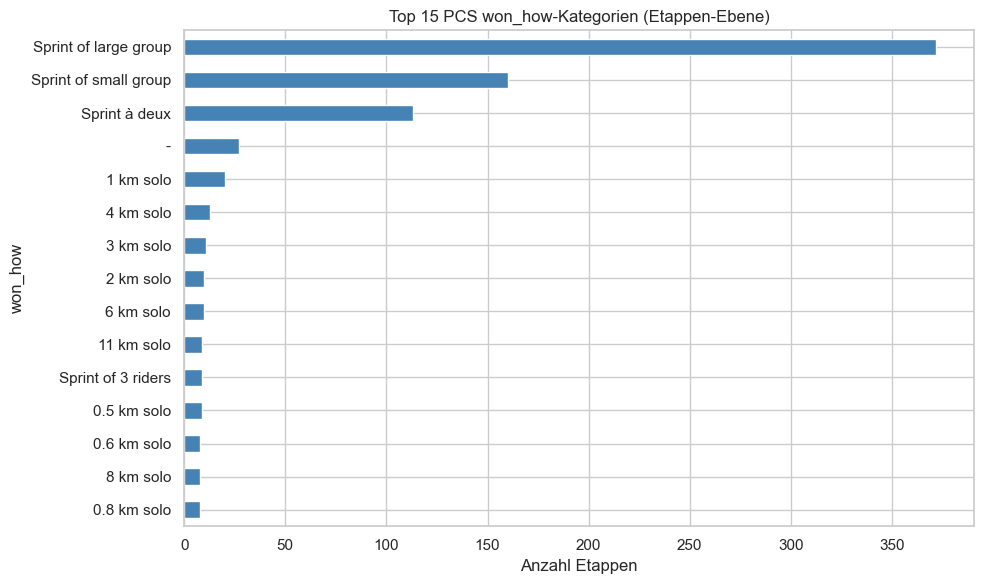

In [6]:
top_n = 15
top_raw = vc_stage.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
top_raw.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Top {top_n} PCS won_how-Kategorien (Etappen-Ebene)")
ax.set_xlabel("Anzahl Etappen")
plt.tight_layout()
plt.show()

### 3.2 Grobklassen (`wh_cat`)

In [7]:
def dist_table(series, label):
    t = series.value_counts().reindex(WH_CAT_ORDER, fill_value=0)
    t = t[t > 0]
    out = t.to_frame("count")
    out["pct"] = (100 * out["count"] / out["count"].sum()).round(2)
    print(f"--- {label} ---")
    display(out)
    return out

dist_rider = dist_table(df["wh_cat"], "Grobklassen (Fahrer-Zeilen)")
dist_stage = dist_table(stages["wh_cat"], "Grobklassen (Etappen)")

--- Grobklassen (Fahrer-Zeilen) ---


,count,pct
wh_cat,,
sprint_large_group,64862,33.08
sprint_small_group,27233,13.89
sprint_two_up,18592,9.48
sprint_n_riders,3305,1.69
solo_or_attack,77264,39.41
missing_placeholder,4018,2.05
other,774,0.39


--- Grobklassen (Etappen) ---


,count,pct
wh_cat,,
sprint_large_group,372,31.90
sprint_small_group,160,13.72
sprint_two_up,113,9.69
sprint_n_riders,21,1.80
solo_or_attack,468,40.14
missing_placeholder,27,2.32
other,5,0.43


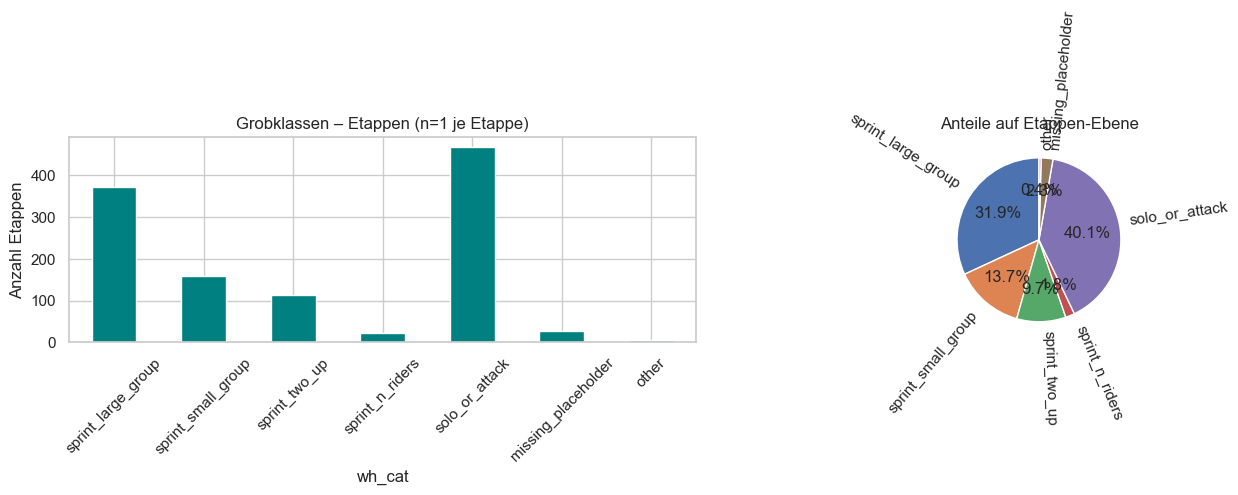

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stage_counts = stages["wh_cat"].value_counts().reindex(WH_CAT_ORDER, fill_value=0)
stage_counts = stage_counts[stage_counts > 0]

stage_counts.plot(kind="bar", ax=axes[0], color="teal", rot=45)
axes[0].set_title("Grobklassen – Etappen (n=1 je Etappe)")
axes[0].set_ylabel("Anzahl Etappen")

axes[1].pie(
    stage_counts.values,
    labels=stage_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    rotatelabels = True
)
axes[1].set_title("Anteile auf Etappen-Ebene")

plt.tight_layout()
plt.show()

Etappen pro Rennen/Jahr und Grobklasse (Auszug – Summen pro Rennen):


wh_cat,sprint_large_group,sprint_small_group,sprint_two_up,sprint_n_riders,solo_or_attack,missing_placeholder,other
race,,,,,,,
giro-d-italia,125,54,37,8,147,8,2
tour-de-france,143,49,31,7,157,6,2
vuelta-a-espana,104,57,45,6,164,13,1


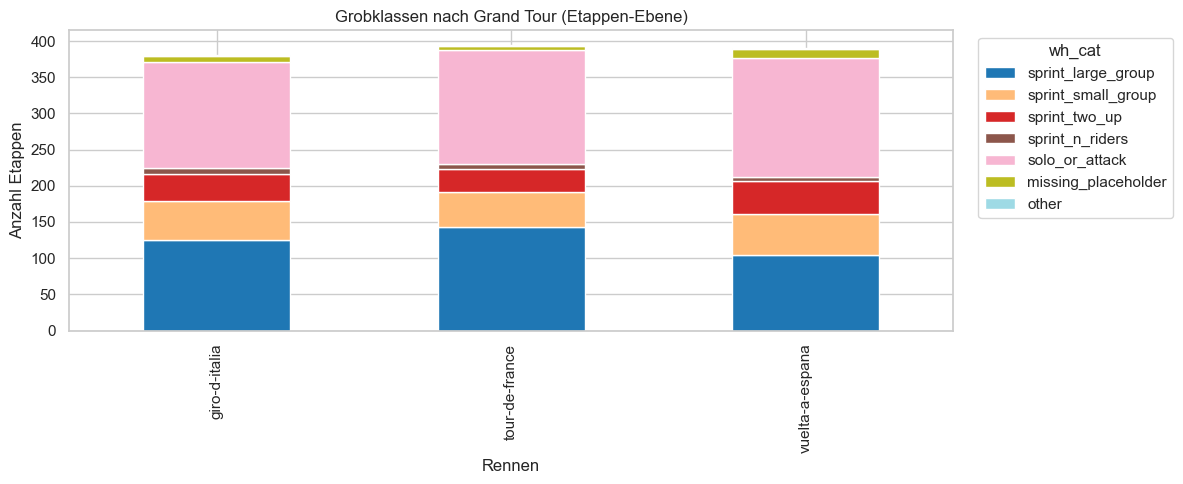

In [9]:
race_year = (
    stages.groupby(["race", "year", "wh_cat"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=WH_CAT_ORDER, fill_value=0)
)
race_year = race_year.loc[:, (race_year.sum(axis=0) > 0)]

print("Etappen pro Rennen/Jahr und Grobklasse (Auszug – Summen pro Rennen):")
by_race = stages.groupby(["race", "wh_cat"]).size().unstack(fill_value=0)
by_race = by_race.reindex(columns=[c for c in WH_CAT_ORDER if c in by_race.columns], fill_value=0)
display(by_race)

fig, ax = plt.subplots(figsize=(12, 5))
by_race.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Grobklassen nach Grand Tour (Etappen-Ebene)")
ax.set_xlabel("Rennen")
ax.set_ylabel("Anzahl Etappen")
ax.legend(title="wh_cat", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 3.3 Solo-Unterkategorien (PCS-Granularität)
Viele Einträge kodieren die Angriffsdistanz in km (z. B. „4 km solo“).

Solo/Attack-Zeilen: 77,264
Mit extrahierter km-Angabe: 76,957


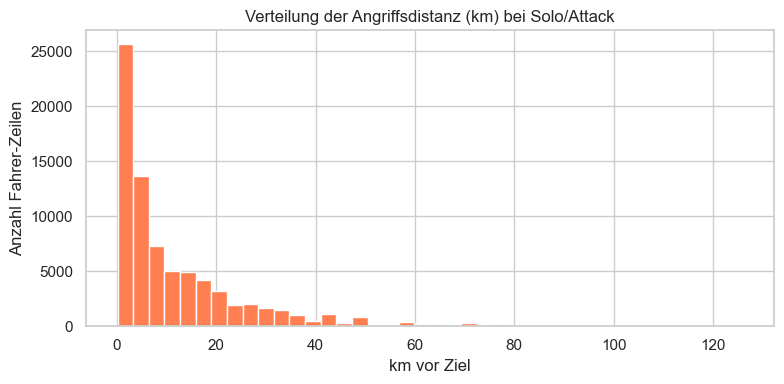

In [10]:
solo_mask = df["wh_cat"] == "solo_or_attack"
solo_km = df.loc[solo_mask, "won_how"].astype(str).str.extract(
    r"(?P<km>\d+(?:\.\d+)?)\s*km", flags=re.IGNORECASE
)["km"].astype(float)

print(f"Solo/Attack-Zeilen: {solo_mask.sum():,}")
print(f"Mit extrahierter km-Angabe: {solo_km.notna().sum():,}")

if solo_km.notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    solo_km.dropna().hist(bins=40, ax=ax, color="coral", edgecolor="white")
    ax.set_title("Verteilung der Angriffsdistanz (km) bei Solo/Attack")
    ax.set_xlabel("km vor Ziel")
    ax.set_ylabel("Anzahl Fahrer-Zeilen")
    plt.tight_layout()
    plt.show()

## 4. Bezug zum Streckenprofil (nur EDA)
Zum **Verständnis**, warum Sprint- und Solo-Etappen unterschiedliche Profile haben — **ohne** `won_how` als Feature zu rechtfertigen. Pre-race-Proxies: `distance`, `vertical_meters`.

> `profile_score` ist im aktuellen Pickle `20_cleaned_master_data.pkl` nicht enthalten.

Kreuztabelle wh_cat x Höhenmeter-Quartil (Etappen):


vm_bin,"(121.999, 1660.75]","(1660.75, 2608.5]","(2608.5, 3660.75]","(3660.75, 6939.0]"
wh_cat,,,,
missing_placeholder,1.000,0.000,0.000,0.000
other,0.000,0.000,0.200,0.800
solo_or_attack,0.041,0.165,0.333,0.462
sprint_large_group,0.548,0.341,0.108,0.003
sprint_n_riders,0.000,0.571,0.381,0.048
sprint_small_group,0.219,0.319,0.262,0.200
sprint_two_up,0.062,0.212,0.389,0.336



Kreuztabelle wh_cat x Distanz-Quartil (Etappen):


dist_bin,"(59.499, 162.525]","(162.525, 181.0]","(181.0, 198.35]","(198.35, 264.0]"
wh_cat,,,,
missing_placeholder,0.778,0.111,0.111,0.000
other,0.200,0.200,0.000,0.600
solo_or_attack,0.248,0.269,0.244,0.239
sprint_large_group,0.220,0.250,0.274,0.255
sprint_n_riders,0.238,0.476,0.190,0.095
sprint_small_group,0.225,0.181,0.262,0.331
sprint_two_up,0.274,0.363,0.124,0.239


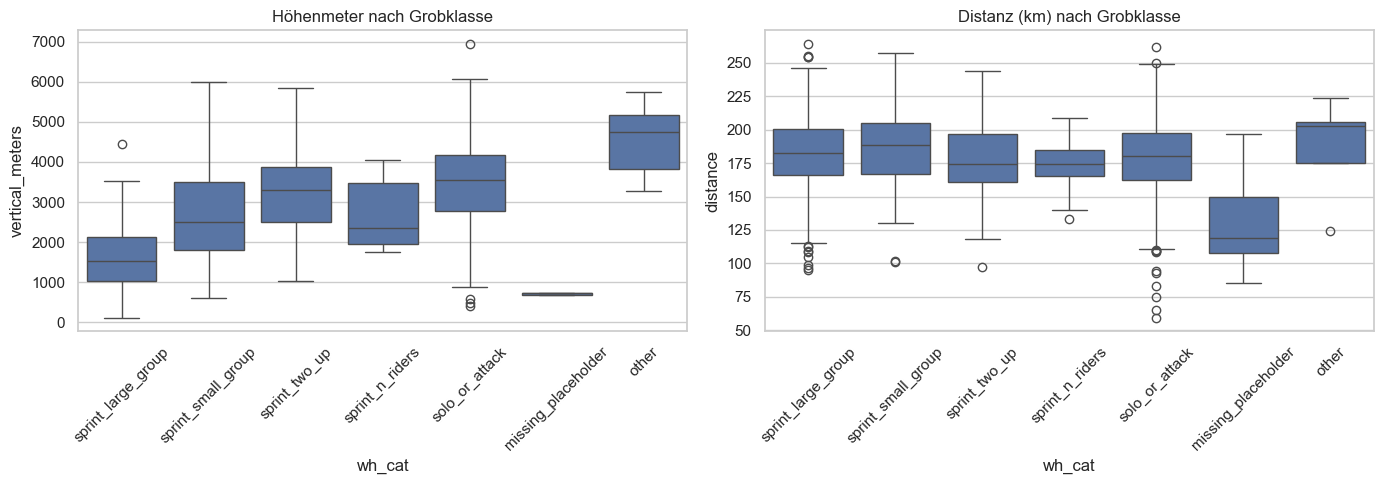

In [11]:
stage_profile = stages[["url", "wh_cat", "distance", "vertical_meters"]].copy()
stage_profile["distance"] = pd.to_numeric(stage_profile["distance"], errors="coerce")
stage_profile["vertical_meters"] = pd.to_numeric(stage_profile["vertical_meters"], errors="coerce")

stage_profile["vm_bin"] = pd.qcut(
    stage_profile["vertical_meters"].dropna(),
    q=4,
    duplicates="drop",
)
stage_profile["dist_bin"] = pd.qcut(
    stage_profile["distance"].dropna(),
    q=4,
    duplicates="drop",
)

print("Kreuztabelle wh_cat x Höhenmeter-Quartil (Etappen):")
ct_vm = pd.crosstab(stage_profile["wh_cat"], stage_profile["vm_bin"], normalize="index").round(3)
display(ct_vm)

print("\nKreuztabelle wh_cat x Distanz-Quartil (Etappen):")
ct_dist = pd.crosstab(stage_profile["wh_cat"], stage_profile["dist_bin"], normalize="index").round(3)
display(ct_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ["vertical_meters", "distance"],
    ["Höhenmeter", "Distanz (km)"],
):
    sns.boxplot(data=stage_profile, x="wh_cat", y=col, ax=ax, order=[c for c in WH_CAT_ORDER if c in stage_profile["wh_cat"].unique()])
    ax.set_title(f"{title} nach Grobklasse")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 4.1 Zusammenhang mit `rank` (illustriert Outcome-Struktur)
Unterschiedliche Median-Ränge reflektieren, dass `won_how` die **bereits eingetretene** Etappen-Dynamik beschreibt — kein Argument für die Nutzung als Feature.

In [12]:
rank_by_cat = df.groupby("wh_cat")["rank"].agg(["count", "median", "std"]).round(2)
rank_by_cat = rank_by_cat.reindex([c for c in WH_CAT_ORDER if c in rank_by_cat.index])
display(rank_by_cat)

,count,median,std
wh_cat,,,
sprint_large_group,64862,88.0,52.01
sprint_small_group,27233,86.0,51.14
sprint_two_up,18592,83.0,49.56
sprint_n_riders,3305,80.0,47.20
solo_or_attack,77264,83.0,49.40
missing_placeholder,4018,76.0,44.39
other,774,79.0,46.19


## 5. Data-Leakage-Bewertung

**Empfehlung: hohes Leakage-Risiko — `won_how` für die Vorhersage von `rank` streichen** (vgl. [08_Feature_Selection.md](08_Feature_Selection.md)).

### Argumentation
1. **Zeitliche Verfügbarkeit:** `won_how` beschreibt das **realisierte** Renngeschehen und steht erst **nach** dem Zieleinlauf fest — analog zu `avg_speed` und `time_gap`.
2. **Kein Rider-Leak, aber Stage-Outcome-Leak:** Der Wert ist pro Etappe für alle Fahrer identisch. Er verrät nicht „dieser Fahrer fuhr solo“, sondern „die Etappe endete als Sprint/Solo“. Das ist dennoch **Post-Outcome-Information** auf derselben Beobachtungseinheit, für die `rank` vorhergesagt werden soll.
3. **Mechanischer Zusammenhang:** Sprint-Etappen erzeugen andere Ranglisten-Strukturen (Massenankunft) als Solo-Etappen. Das Modell könnte `won_how` als Proxy für die **bereits eingetretene** Ergebnisstruktur nutzen.
4. **Abgrenzung:** Fahrer-PCS-Scores (`sprint`, `climber`, …) sind **ex-ante**; `won_how` ist **ex-post**.
5. **Legitim nur anderswo:** Als **Label** für eine separate Finish-Type-Klassifikation, oder als historisches Feature aus **vergangenen** Etappen mit striktem Zeit-Split — nicht die aktuelle Etappe.

| Feature | Zeitpunkt | Leakage für `rank` |
|---------|-----------|-------------------|
| `won_how` | post-race | **hoch** |
| `avg_speed` | post-race | **hoch** |
| `time_gap` / `time_gap_seconds` | post-race | **hoch** |
| `vertical_meters` | pre-race | nein |
| `sprint` (Fahrer-Score) | pre-race | nein |

## 6. Transformationsvorschläge für ML

### Primäre Empfehlung (Ranking / XGBRanker)
- **`won_how` nicht encodieren; Spalte vor dem Training droppen.**
- Pre-race-Alternativen: `distance`, `vertical_meters`, `stage_nr`, `race_competitiveness_median`, Fahrer-Spezialisierungen und Team-Stärke.

### Theoretische Optionen (nicht empfohlen für `rank`)

| Ansatz | Pro | Contra |
|--------|-----|--------|
| Roh-One-Hot (~205 Kategorien) | vollständig | sparse, instabil, **Leakage** |
| Grob-One-Hot (6–8 Klassen via `classify_won_how`) | interpretierbar | weiterhin **post-race Leakage** |
| Ordinal Encoding | kompakt | falsche Ordnungsannahme |
| Target Encoding auf `url` | — | zirkulär + Leakage über Zielverteilung |

### Optional (nur mit striktem Zeit-Split)
- Historische Sprint-Quote **ähnlicher** Etappenprofile aus Train-Jahren `<` Test-Jahr — nicht `won_how` der aktuellen Etappe.

### Platzhalter `"-"`
- In der EDA (Abschnitte 2–4) als `missing_placeholder` geführt; die **vollständige Liste betroffener Etappen** und die Imputation stehen in **Abschnitt 8.1**.
- Für `won_how_cat` werden die 27 GT-Zeitfahren als `time_trial` kodiert (fachliche Imputation, siehe 8.3).

## 7. Fazit

- **Verteilung:** Dominieren Massensprints (`sprint_large_group`, `sprint_small_group`) und Solo/Attack-Varianten; PCS liefert zudem viele feine Solo-km-Labels.
- **Etappen-Level:** `won_how` ist auf allen Fahrer-Zeilen einer Etappe konstant — reines Stage-Metadatum.
- **Missing `"-"`:** Betrifft **27 konkrete GT-Zeitfahren** (Abschnitt 8.1), keine zufällige Streuung.
- **Transformation:** `won_how_cat` mit 10 Grobklassen; `"-"` → `time_trial`; Solo bleibt als `solo_or_attack` (kein short/long-Split, siehe 8.2).
- **ML:** Für die Ranking-Pipeline **`won_how` / `won_how_cat` entfernen**; Strecken- und Fahrer-Features decken den erwarteten Etappencharakter **vor** dem Rennen ab.
- **Leakage:** **Hoch** — gleiche Begründung wie bei `avg_speed` und `time_gap`; konsistent mit [08_Feature_Selection.md](08_Feature_Selection.md).

## 8. Transformation: `won_how_cat`

Abschnitt 8 setzt die Taxonomie aus Abschnitt 2 produktiv um: Analyse der Platzhalter `"-"`, km-Auswertung bei Solo/Attack, Erzeugung von `won_how_cat` und Speicherung in `22_cleaned_master_data.pkl`.

> Input: `21_cleaned_master_data.pkl` (nach Weather-Transformation). Output: `22_cleaned_master_data.pkl` — `won_how` durch `won_how_cat` ersetzt.

### 8.1 Platzhalter `"-"` — betroffene Etappen

PCS liefert bei einigen Etappen kein „Won how“. Die vollständige Liste zeigt, **welche konkreten Etappen** betroffen sind.

In [13]:
miss_stages = stages[stages["won_how"] == "-"].sort_values(["race", "year", "stage_nr"])
miss_cols = ["race", "year", "stage_nr", "distance", "vertical_meters", "avg_speed", "url"]

print(f"Etappen mit won_how = '-': {len(miss_stages)}")
print(f"Fahrer-Zeilen betroffen: {(df['won_how'] == '-').sum():,}")
display(miss_stages[miss_cols].reset_index(drop=True))

print("\n--- Aggregation nach Rennen ---")
print(miss_stages.groupby("race").size().to_string())

print("\n--- Aggregation nach stage_nr ---")
print(miss_stages["stage_nr"].value_counts().sort_index().to_string())

print("\n--- Aggregation nach Jahr ---")
print(miss_stages["year"].value_counts().sort_index().to_string())

Etappen mit won_how = '-': 27
Fahrer-Zeilen betroffen: 4,018


,race,year,stage_nr,distance,vertical_meters,avg_speed,url
0,giro-d-italia,2005,20,119.0,692,37.8531,https://www.procyclingstats.com/race/giro-d-it...
1,giro-d-italia,2006,20,140.0,692,38.3389,https://www.procyclingstats.com/race/giro-d-it...
2,giro-d-italia,2007,21,185.0,692,37.5234,https://www.procyclingstats.com/race/giro-d-it...
3,giro-d-italia,2013,21,197.0,692,41.1739,https://www.procyclingstats.com/race/giro-d-it...
4,giro-d-italia,2014,21,172.0,692,39.1598,https://www.procyclingstats.com/race/giro-d-it...
5,giro-d-italia,2015,21,185.0,692,39.6250,https://www.procyclingstats.com/race/giro-d-it...
6,giro-d-italia,2016,21,163.0,692,40.0584,https://www.procyclingstats.com/race/giro-d-it...
7,giro-d-italia,2018,21,115.0,692,40.1109,https://www.procyclingstats.com/race/giro-d-it...
8,tour-de-france,2005,21,144.0,732,41.1594,https://www.procyclingstats.com/race/tour-de-f...
9,tour-de-france,2006,20,154.0,732,40.7900,https://www.procyclingstats.com/race/tour-de-f...



--- Aggregation nach Rennen ---
race
giro-d-italia       8
tour-de-france      6
vuelta-a-espana    13

--- Aggregation nach stage_nr ---
stage_nr
20     5
21    22

--- Aggregation nach Jahr ---
year
2005    3
2006    3
2007    3
2008    2
2009    2
2010    2
2011    1
2012    1
2013    2
2014    1
2015    1
2016    2
2017    1
2018    2
2019    1


**Fazit 8.1:** Alle 27 Etappen mit `"-"` sind **abschließende Zeitfahren** der drei Grand Tours (erkennbar an `vertical_meters`: Giro 692, TdF 732, Vuelta 726; überwiegend Stage 20/21). Keine zufällige Streuung — PCS liefert bei GT-Zeitfahren kein „Won how“.

**Imputation für `won_how_cat`:** `"-"` → `time_trial`.

### 8.2 km-Analyse bei Solo/Attack

Viele PCS-Strings kodieren die Angriffsdistanz (z. B. „4 km solo“). Hier: vollständige Auswertung auf **Etappen-Ebene** und Bewertung, ob `solo_or_attack` in short/long aufgeteilt werden soll.

Solo/Attack-Etappen: 468
Mit extrahierter km-Angabe: 466
Ohne km: 2
Etappen ohne km: ['? km solo', '? km solo']

--- Deskriptive Statistik (Etappen-Ebene) ---


,solo_km
count,466.00
mean,12.28
std,15.87
min,0.10
25%,2.00
50%,6.00
75%,17.00
max,126.00



Perzentile:
0.10     0.72
0.25     2.00
0.50     6.00
0.75    17.00
0.90    30.90


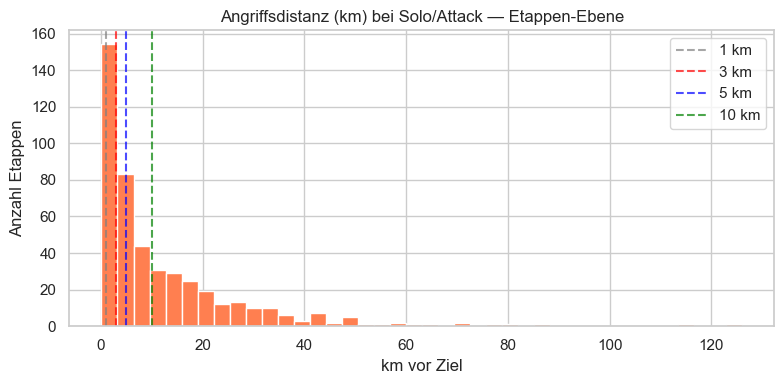


--- Schwellenvergleich (Etappen-Ebene) ---


,Schwellwert_km,short,long,pct_short
0,1,84,382,18.0
1,3,153,313,32.8
2,5,205,261,44.0
3,10,286,180,61.4



--- Median rank nach Solo-Länge (Schwellwert 3 km, Fahrer-Zeilen) ---


,count,median,std
solo_length,,,
long,51510,83.0,49.26
short,25447,84.0,49.74


In [14]:
solo_stages = stages[stages["wh_cat"] == "solo_or_attack"].copy()
solo_stages["solo_km"] = solo_stages["won_how"].astype(str).str.extract(
    r"(?P<km>\d+(?:\.\d+)?)\s*km", flags=re.IGNORECASE
)["km"].astype(float)

print(f"Solo/Attack-Etappen: {len(solo_stages)}")
print(f"Mit extrahierter km-Angabe: {solo_stages['solo_km'].notna().sum()}")
print(f"Ohne km: {solo_stages['solo_km'].isna().sum()}")
if solo_stages["solo_km"].isna().any():
    print("Etappen ohne km:", solo_stages.loc[solo_stages["solo_km"].isna(), "won_how"].tolist())

km_vals = solo_stages["solo_km"].dropna()
print("\n--- Deskriptive Statistik (Etappen-Ebene) ---")
display(km_vals.describe().round(2).to_frame("solo_km"))

pct = km_vals.quantile([0.1, 0.25, 0.5, 0.75, 0.9])
print("\nPerzentile:")
print(pct.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
km_vals.hist(bins=40, ax=ax, color="coral", edgecolor="white")
for thresh, color in [(1, "gray"), (3, "red"), (5, "blue"), (10, "green")]:
    ax.axvline(thresh, color=color, linestyle="--", alpha=0.7, label=f"{thresh} km")
ax.set_title("Angriffsdistanz (km) bei Solo/Attack — Etappen-Ebene")
ax.set_xlabel("km vor Ziel")
ax.set_ylabel("Anzahl Etappen")
ax.legend()
plt.tight_layout()
plt.show()

thresh_rows = []
for thresh in [1, 3, 5, 10]:
    short = (km_vals <= thresh).sum()
    long = (km_vals > thresh).sum()
    total = short + long
    thresh_rows.append({
        "Schwellwert_km": thresh,
        "short": short,
        "long": long,
        "pct_short": round(short / total * 100, 1),
    })
print("\n--- Schwellenvergleich (Etappen-Ebene) ---")
display(pd.DataFrame(thresh_rows))

solo_stages_valid = solo_stages.dropna(subset=["solo_km"]).copy()
solo_stages_valid["solo_length"] = np.where(solo_stages_valid["solo_km"] <= 3, "short", "long")
df_solo = df.merge(solo_stages_valid[["url", "solo_length"]], on="url", how="inner")
print("\n--- Median rank nach Solo-Länge (Schwellwert 3 km, Fahrer-Zeilen) ---")
display(df_solo.groupby("solo_length")["rank"].agg(["count", "median", "std"]).round(2))

#### Entscheidung: short/long in `won_how_cat`?

**Empfehlung: Nein — `solo_or_attack` als eine Kategorie beibehalten.**

| Argument | Befund |
|----------|--------|
| Schwellenwert | Median 6 km, Häufung bei 1–3 km — kein eindeutiges Optimum |
| Outcome-Signal | Median `rank` short (84) vs. long (83) — praktisch identisch |
| Kardinalität | Mehr Kategorien ohne klareren Grobklassen-Nutzen |
| ML-Kontext | `won_how_cat` ist post-race; feinere Splits ändern das nicht |

**Wann wäre short/long sinnvoll?** Wenn man bewusst zwei Szenarien trennen will: *short solo* (≤3 km, späte Attacke/Positionierung) vs. *long solo* (>3 km, Ausreißer-/Bergetappe). Dann braucht es eine **explizit begründete** Schwelle.

#### Schwellenwert-Berechnung (Methodenvergleich)

| Methode | Ergebnis hier | Bewertung |
|---------|---------------|----------|
| **Domänenwissen** (Radsport: späte Attacke ≤3 km) | 3 km | interpretierbar, PCS-Häufung bei 1–3 km |
| **Median** | 6 km | robust, trennt Häufung bei 1–3 km schlecht |
| **Perzentil (33/66)** | ~2 km / ~17 km | datengetrieben, schwer erklärbar |
| **Outcome-basiert** (`rank`) | kaum Trennung | hier ungeeignet |

**Fazit:** Falls man später splitten würde, wäre **3 km** die vertretbarste Wahl. Für `won_how_cat` bleibt es bei **`solo_or_attack`**.

### 8.3 Transformation: `won_how_to_cat`

Finale Kategorien (10 Klassen, ohne `missing_placeholder`):

`sprint_large_group` · `sprint_small_group` · `sprint_two_up` · `sprint_n_riders` · `sprint_other` · `solo_or_attack` · `time_trial` · `reduced_group` · `breakaway` · `other`

In [15]:
WON_HOW_CAT_ORDER = [
    "sprint_large_group",
    "sprint_small_group",
    "sprint_two_up",
    "sprint_n_riders",
    "sprint_other",
    "solo_or_attack",
    "time_trial",
    "reduced_group",
    "breakaway",
    "other",
]


def won_how_to_cat(value) -> str:
    """PCS won_how -> finale Grobklasse für won_how_cat."""
    s = str(value).strip().lower()
    if s == "-":
        return "time_trial"
    if s in ("n/a", "nan", ""):
        return "other"
    if "trial" in s:
        return "time_trial"
    if "sprint" in s:
        if "large" in s:
            return "sprint_large_group"
        if "small" in s:
            return "sprint_small_group"
        if "deux" in s or "two" in s:
            return "sprint_two_up"
        if re.search(r"sprint of \d", s):
            return "sprint_n_riders"
        return "sprint_other"
    if "solo" in s or "attack" in s:
        return "solo_or_attack"
    if "reduced" in s:
        return "reduced_group"
    if "breakaway" in s or "break" in s:
        return "breakaway"
    return "other"


df_21 = pd.read_pickle("../../data/processed/21_cleaned_master_data.pkl")
df_21["won_how_cat"] = df_21["won_how"].map(won_how_to_cat)
df_21["won_how_cat"] = pd.Categorical(df_21["won_how_cat"], categories=WON_HOW_CAT_ORDER, ordered=True)

print(f"Geladen: 21_cleaned_master_data.pkl — {df_21.shape[0]:,} Zeilen x {df_21.shape[1]} Spalten")
print(f"won_how_cat: {df_21['won_how_cat'].nunique()} Kategorien")

Geladen: 21_cleaned_master_data.pkl — 196,048 Zeilen x 61 Spalten
won_how_cat: 7 Kategorien


In [16]:
cat_per_stage = df_21.groupby("url")["won_how_cat"].nunique()
assert cat_per_stage.max() == 1, "won_how_cat ist nicht etappenkonstant!"

mapping = (
    df_21[["won_how", "won_how_cat"]]
    .drop_duplicates()
    .sort_values("won_how")
    .reset_index(drop=True)
)
print(f"Mapping: {mapping['won_how'].nunique()} Rohwerte -> {mapping['won_how_cat'].nunique()} Kategorien")
display(mapping)

stages_21 = df_21.drop_duplicates(subset="url")
print("\n--- won_how_cat Verteilung (Etappen-Ebene) ---")
cat_dist = stages_21["won_how_cat"].value_counts().reindex(WON_HOW_CAT_ORDER, fill_value=0)
display(cat_dist.to_frame("etappen"))

imputed = stages_21[stages_21["won_how"] == "-"][["race", "year", "stage_nr", "won_how", "won_how_cat"]]
print(f"\nImputierte TT-Etappen ('-' -> time_trial): {len(imputed)}")
display(imputed)

Mapping: 205 Rohwerte -> 7 Kategorien


,won_how,won_how_cat
0,-,time_trial
1,0.1 km solo,solo_or_attack
2,0.15 km solo,solo_or_attack
3,0.17 km solo,solo_or_attack
4,0.2 km solo,solo_or_attack
...,...,...
200,Sprint of 8 riders,sprint_n_riders
201,Sprint of 9 riders,sprint_n_riders
202,Sprint of large group,sprint_large_group
203,Sprint of small group,sprint_small_group



--- won_how_cat Verteilung (Etappen-Ebene) ---


,etappen
won_how_cat,
sprint_large_group,372
sprint_small_group,160
sprint_two_up,113
sprint_n_riders,21
sprint_other,0
solo_or_attack,468
time_trial,27
reduced_group,0
breakaway,0



Imputierte TT-Etappen ('-' -> time_trial): 27


,race,year,stage_nr,won_how,won_how_cat
2895,tour-de-france,2005,21,-,time_trial
5803,tour-de-france,2006,20,-,time_trial
8841,tour-de-france,2007,20,-,time_trial
11937,tour-de-france,2008,21,-,time_trial
14943,tour-de-france,2009,21,-,time_trial
18366,tour-de-france,2010,20,-,time_trial
70143,giro-d-italia,2005,20,-,time_trial
73145,giro-d-italia,2006,20,-,time_trial
76025,giro-d-italia,2007,21,-,time_trial
94597,giro-d-italia,2013,21,-,time_trial


### 8.4 Pickle speichern

Speichert `22_cleaned_master_data.pkl` — `21_` mit `won_how` **ersetzt** durch `won_how_cat` (keine zusätzliche Spalte).

In [17]:
df_21 = df_21.drop(columns=["won_how"])

pfad = "../../data/processed/22_cleaned_master_data.pkl"
df_21.to_pickle(pfad)
print(f"Gespeichert: {pfad}")
print(f"Shape: {df_21.shape[0]:,} Zeilen x {df_21.shape[1]} Spalten")

df_check = pd.read_pickle(pfad)
cols_21 = pd.read_pickle("../../data/processed/21_cleaned_master_data.pkl").columns.tolist()
expected_cols = (set(cols_21) - {"won_how"}) | {"won_how_cat"}
assert set(df_check.columns) == expected_cols
assert "won_how" not in df_check.columns
assert df_check["won_how_cat"].notna().all()
print(f"Smoke-Test OK: won_how_cat vorhanden, {df_check['won_how_cat'].nunique()} Kategorien")

Gespeichert: ../../data/processed/22_cleaned_master_data.pkl
Shape: 196,048 Zeilen x 61 Spalten
Smoke-Test OK: won_how_cat vorhanden, 7 Kategorien
